**Import Required Libraries**

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Load Dataset**

In [3]:
# Load Housing Dataset

df = pd.read_csv("housing dataset for task 4.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


**Display First 5 Rows**

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


**Dataset Shape**

In [5]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 545
Number of Columns: 13


**Column Names**

In [6]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


**Data Types**

In [7]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


**Dataset Information**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


**Missing Values**

In [9]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


**Duplicate Values**

In [11]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


**Descriptive Statistics**

In [12]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


**Exploratory Data Analysis**

Price Distribution

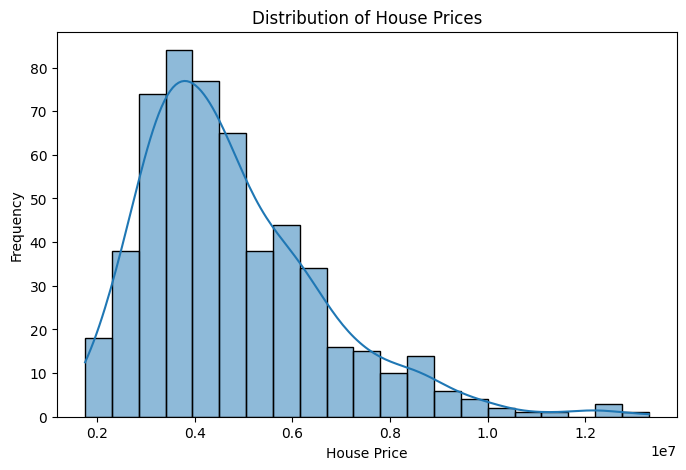

In [13]:

plt.figure(figsize=(8, 5))

sns.histplot(df['price'], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

**Area vs Price**

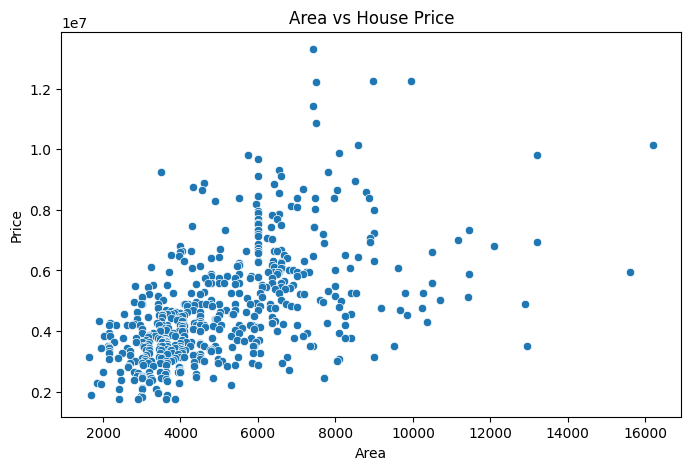

In [14]:

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='area', y='price')

plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

**Bedrooms vs Price**

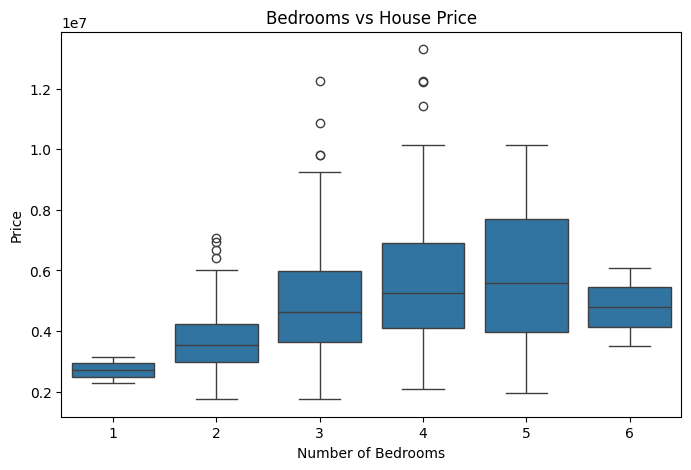

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='bedrooms', y='price')

plt.title("Bedrooms vs House Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")

plt.show()

**Bathrooms vs Price**

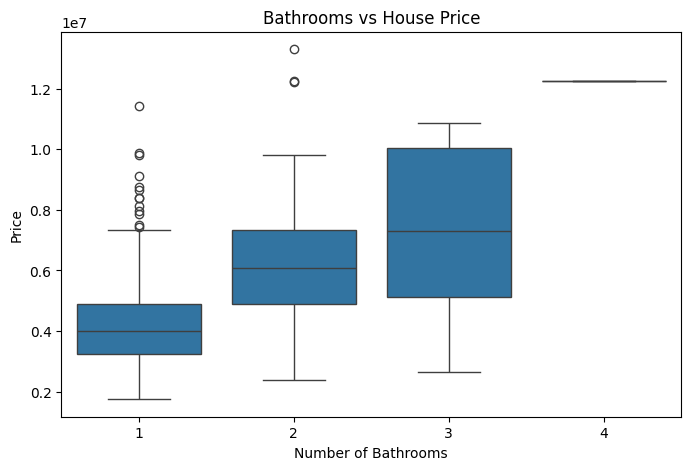

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='bathrooms', y='price')

plt.title("Bathrooms vs House Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price")

plt.show()

**Feature Identification**

Numerical Features

In [17]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Features:")
print(numerical_features.tolist())

Numerical Features:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']


**Categorical Features**

In [18]:

categorical_features = df.select_dtypes(include=['object']).columns

print("Categorical Features:")
print(categorical_features.tolist())

Categorical Features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


**Data Preprocessing**

Convert Categorical Variables

In [19]:
# Convert Binary Categorical Columns into Numerical Values

binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for column in binary_columns:
    df[column] = df[column].map({'yes': 1, 'no': 0})

print("Binary categorical columns converted successfully.")

Binary categorical columns converted successfully.


**One-Hot Encoding**

In [20]:
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True,
    dtype=int
)

print("One-Hot Encoding completed.")

One-Hot Encoding completed.


**Check Processed Dataset**

In [21]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


**Correlation Analysis**

Correlation Matrix

In [22]:
correlation_matrix = df.corr()

correlation_matrix

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.296898,0.255517,0.187057,0.093073,0.452954,0.384394,0.329777,0.063656,-0.280587
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,-0.009229,0.222393,0.352980,0.234779,0.006156,-0.142278
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,-0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.079023,0.050040,-0.126252
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.063472,0.029834,-0.132107
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,-0.172394,0.018847,0.293602,0.045547,0.044425,-0.003648,-0.082972
mainroad,0.296898,0.288874,-0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,0.204433,0.199876,0.011450,-0.133123
guestroom,0.255517,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,0.037466,0.160897,0.005821,-0.099023
basement,0.187057,0.047417,0.097312,0.102106,-0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.228083,0.050284,-0.117935
hotwaterheating,0.093073,-0.009229,0.046049,0.067159,0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,0.067864,-0.059411,0.063819,-0.059194
airconditioning,0.452954,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,0.159173,0.117382,-0.053179,-0.094086


**Correlation Heatmap**

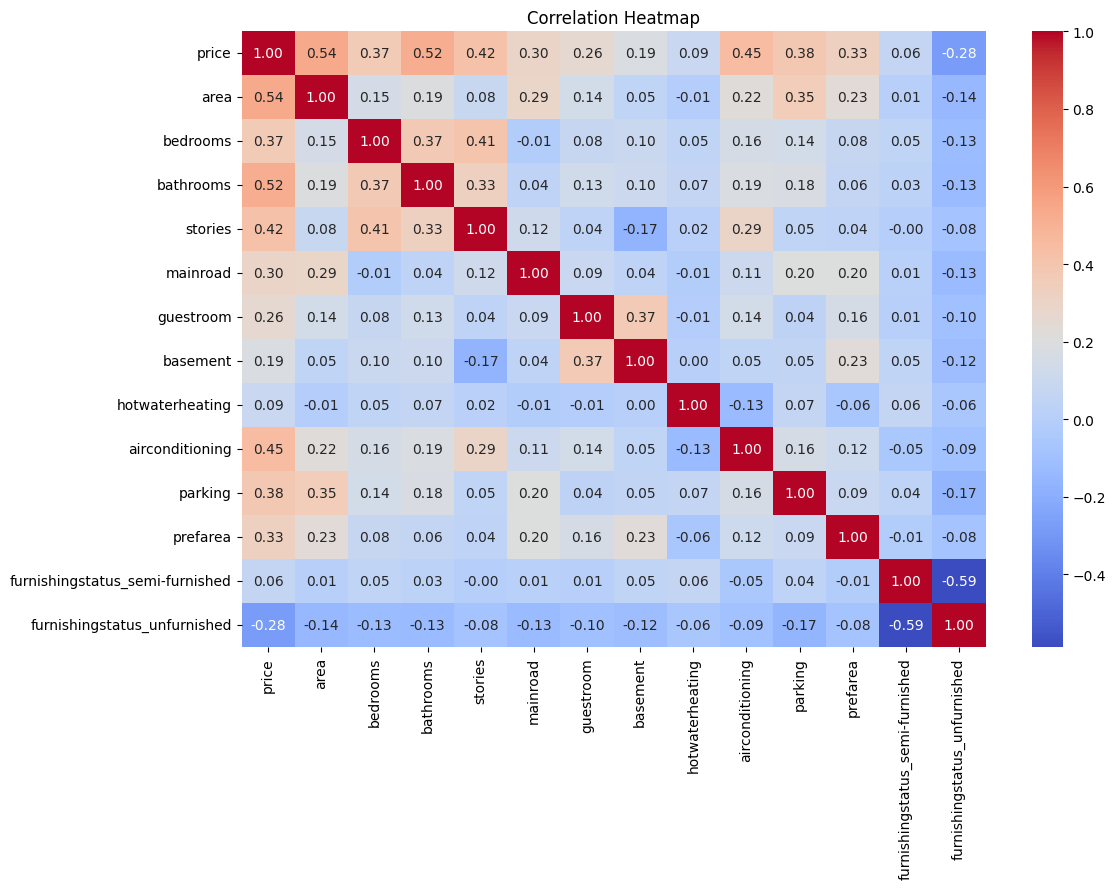

In [23]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

**Feature Selection**

In [24]:
# Define Features (X) and Target (y)

X = df.drop('price', axis=1)
y = df['price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (545, 13)
Target shape: (545,)


**Train-Test Split**

In [25]:
# Split Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 13)
Testing data: (109, 13)


**Linear Regression**

In [26]:
# Create Linear Regression Model

model = LinearRegression()
print("Linear Regression model created.")

Linear Regression model created.


**Train Model**

In [27]:
model.fit(X_train, y_train)
print("Model training completed successfully.")

Model training completed successfully.


**Make Predictions**

In [28]:
y_pred = model.predict(X_test)
print("Predictions generated successfully.")

Predictions generated successfully.


**Model Evaluation**

In [30]:
# Mean Squared Error (MSE)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

# Root Mean Squared Error (RMSE)

rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

# R² Score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

Mean Squared Error (MSE): 1754318687330.6633
Root Mean Squared Error (RMSE): 1324506.9600914384
R² Score: 0.6529242642153185


In [31]:
# Final Model Evaluation

print("Model Evaluation Results")
print("-------------------------")
print("MSE  :", mse)
print("RMSE :", rmse)
print("R² Score:", r2)

Model Evaluation Results
-------------------------
MSE  : 1754318687330.6633
RMSE : 1324506.9600914384
R² Score: 0.6529242642153185


**Actual vs Predicted**

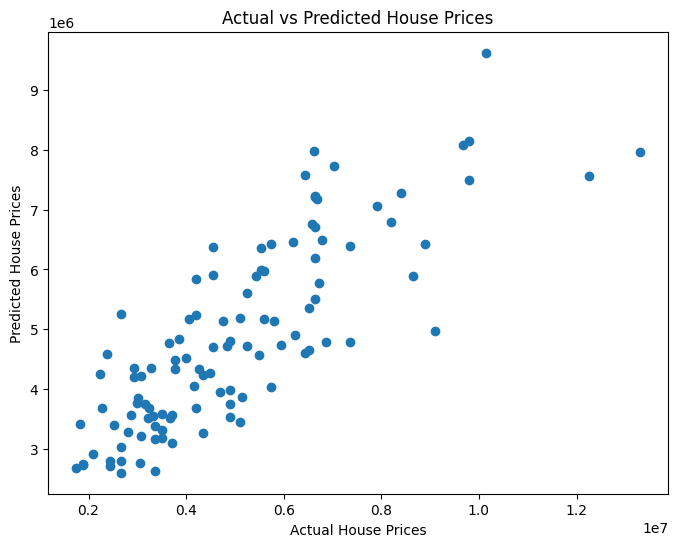

In [32]:
# Actual vs Predicted House Prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

**Regression Line Reference**

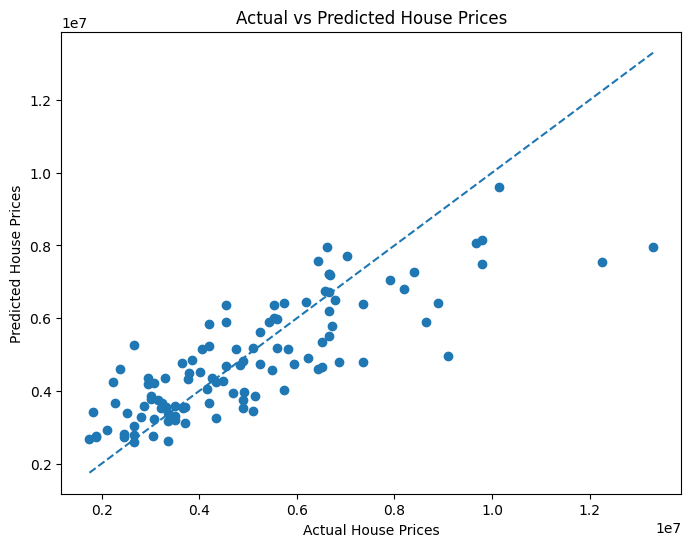

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

**Prediction Comparison**

In [34]:
# Compare Actual and Predicted Prices

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06
5,4900000,3.532275e+06
6,5250000,5.611775e+06
7,4543000,6.368146e+06
8,2450000,2.722857e+06
9,3353000,2.629406e+06


**Feature Coefficients**

In [35]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05
1,bedrooms,7.677870e+04


**Final Conclusion**

In [36]:
# Final Results

print("Task 4 - House Price Prediction")
print("--------------------------------")
print("Model: Linear Regression")
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Task 4 - House Price Prediction
--------------------------------
Model: Linear Regression
Training Samples: 436
Testing Samples: 109
MSE: 1754318687330.6633
RMSE: 1324506.9600914384
R² Score: 0.6529242642153185
